/tmp/ipykernel_37874/2520488020.py:43: RuntimeWarning: invalid value encountered in scalar divide
  matriz_transiciones[i][j] = (matriz[i][j])/filas_sumadas[i]


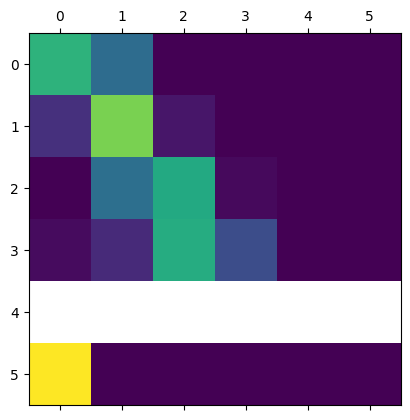

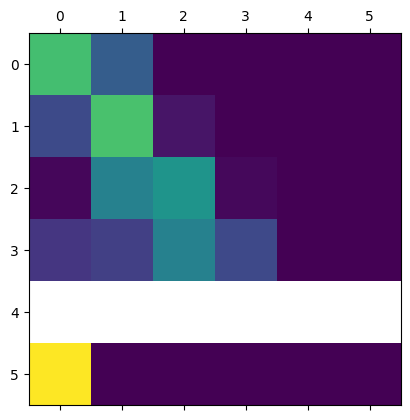

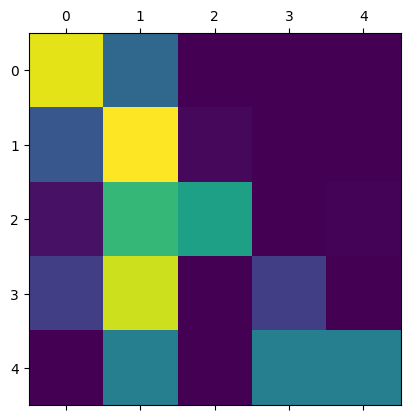

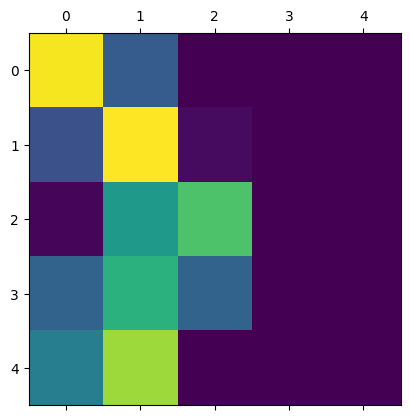

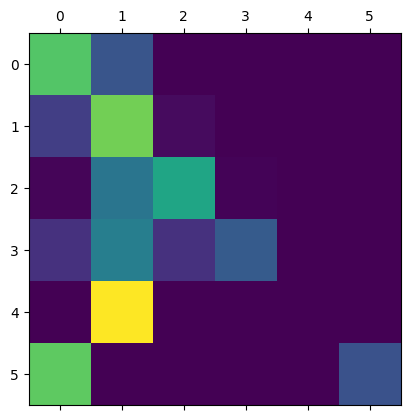

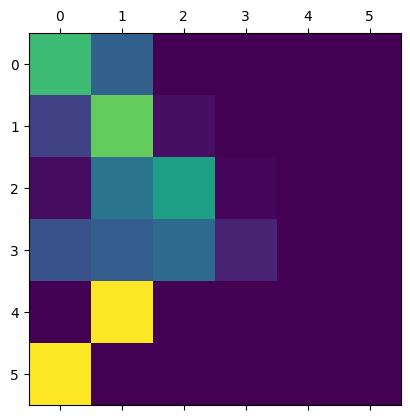

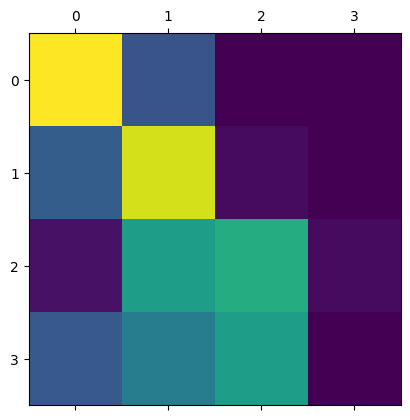

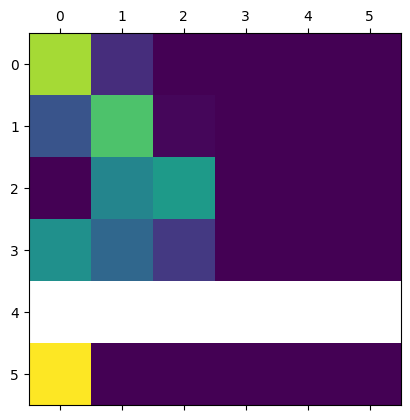

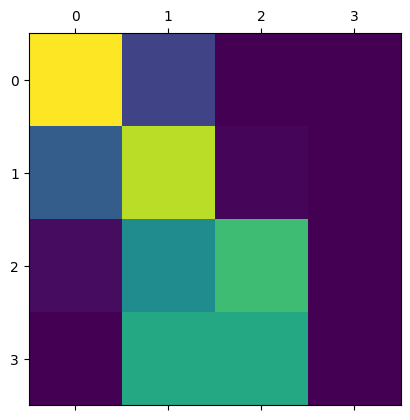

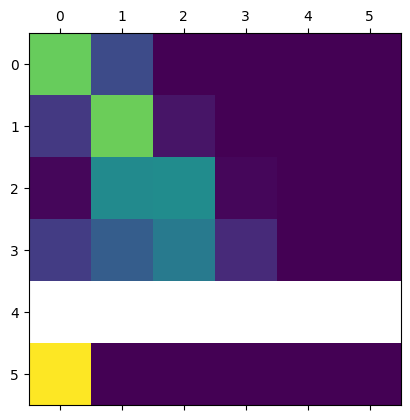

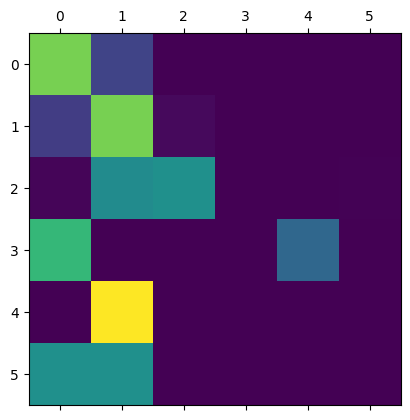

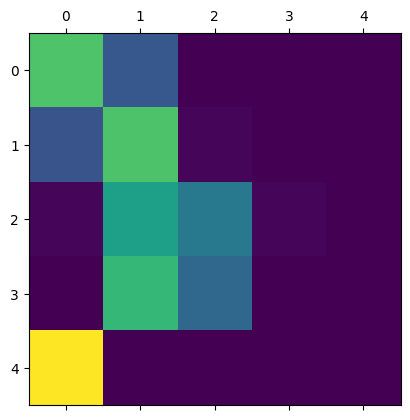

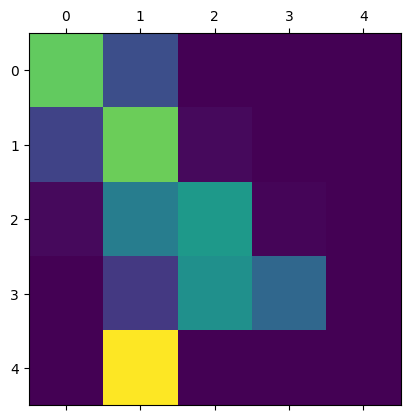

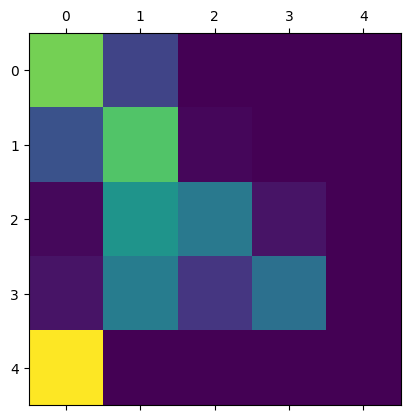

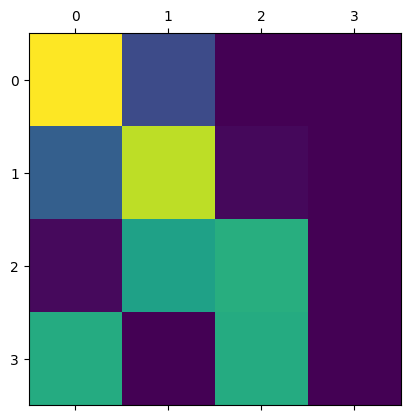

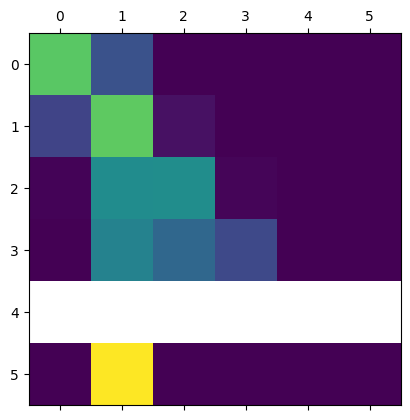

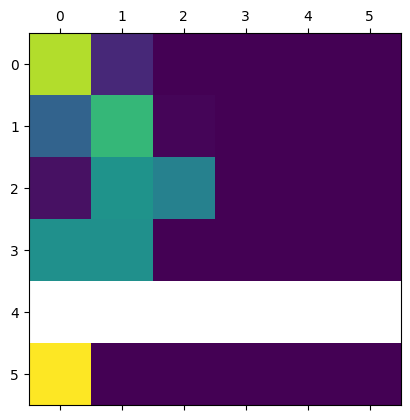

In [6]:
import numpy as np
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import pprint
from collections import defaultdict
from scipy.spatial import Voronoi
import geopandas as gpd
from shapely.geometry import Polygon, Point
# Función para calcular la matriz de conteo de transiciones a partir de una secuencia dada
def calcular_matriz_conteo_transiciones(secuencia):
    transiciones = defaultdict(int)

    # Conteo de transiciones
    for i in range(len(secuencia) - 1):
        transicion = (secuencia[i], secuencia[i + 1])
        transiciones[transicion] += 1

    # Obtener el número de estados
    num_estados = max(max(transiciones.keys())) + 1

    # Crear matriz de conteo de transiciones
    matriz_conteo_transiciones = np.zeros((num_estados, num_estados), dtype=int)

    # Llenar la matriz con los conteos
    for transicion, conteo in transiciones.items():
        origen, destino = transicion
        matriz_conteo_transiciones[origen][destino] = conteo

    return matriz_conteo_transiciones


#Funcion para hallar la matriz de trasicion, en base a la matriz de conteo
def matriz_transicion(matriz, n):
    filas_sumadas = []
    matriz_transiciones = np.zeros((n,n), dtype=float)
    for fila in matriz:
        suma_fila = sum(fila)
        filas_sumadas.append(suma_fila)

    for i in range(n):
      for j in range(n):
        matriz_transiciones[i][j] = (matriz[i][j])/filas_sumadas[i]

    return matriz_transiciones


#datos

df = pd.read_csv('/content/calidad_aire.csv')

estaciones = [12, 28, 38, 69, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 94]


# Diccionario para almacenar los DataFrames
dfs = {}

# Clasifica y crea un nuevo DataFrame para cada estacion
for estacion in estaciones:
    dfs[estacion] = df[df['codigoSerial'] == estacion]
for i in estaciones:
  num_filas = dfs[i].shape[0]
  #imprime la cantidad de filas(datos de cada data frame)
  #print(f'El DataFrame {i} tiene {num_filas} filas')

listas_pm25 = {}
cantidad = [0, 0, 0, 0, 0, 0]

for estacion in dfs.keys():
    listas_pm25[estacion] = []


    # No se añade nada a la lista si no cumple con las condiciones
    for valor in dfs[estacion]['pm25']:
        if 0 <= valor <= 15.4:
            listas_pm25[estacion].append(0)
            cantidad[0]+=1
        elif 15.5 <= valor <= 40.4:
            listas_pm25[estacion].append(1)
            cantidad[1]+=1
        elif 40.5 <= valor <= 65.4:
            listas_pm25[estacion].append(2)
            cantidad[2]+=1
        elif 65.5 <= valor <= 150.4:
            listas_pm25[estacion].append(3)
            cantidad[3]+=1
        elif 150.5 <= valor <= 240.4:
            listas_pm25[estacion].append(4)
            cantidad[4]+=1
        elif 240.5 <= valor <= 500.4:
            listas_pm25[estacion].append(5)
            cantidad[5]+=1

#conocer los datos
""" print(f'Hay un total de {len(df)} datos')
print(f'Hay un total de {sum(cantidad)} datos validos (es decir un pm2.5 entre 0 y 500)')
for i in range(6):
    print(f'para el estado {i} hay {cantidad[i]} datos')"""


matrices_transicion = {}

for estacion in dfs.keys():
    # Calcula la matriz de conteo de transiciones para la lista de la estación actual
    matriz_conteo_transiciones = calcular_matriz_conteo_transiciones(listas_pm25[estacion])

    # Calcula la matriz de transición a partir de la matriz de conteo
    n = len(matriz_conteo_transiciones)
    matriz_transicion_estacion = matriz_transicion(matriz_conteo_transiciones, n)

    # Almacena la matriz de transición en el diccionario
    matrices_transicion[estacion] = matriz_transicion_estacion

    # Imprime la matriz de transición
    plt.matshow(matriz_transicion_estacion)
    #plt.colorbar()  # Añade una barra de colores para interpretar los valores
    #plt.title(f'Matriz de transición para la estación {estacion}')
    #plt.show()
    # plt.savefig('matriz_transicion_estacion_' + str(estacion)+'.png')

Index(['longitud', 'latitud', 'geometry', 'index_right'], dtype='object')
Claves en matrices_transicion: dict_keys([28, 38, 69, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 94])
Claves en W_normalized: dict_keys([28, 38, 69, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 94])


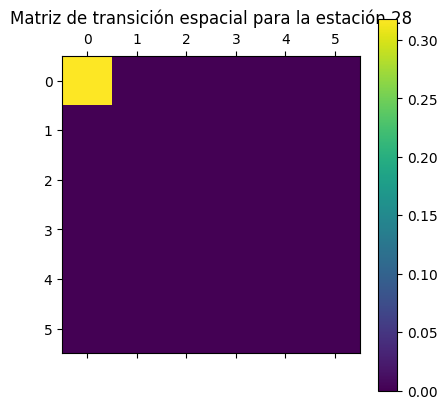

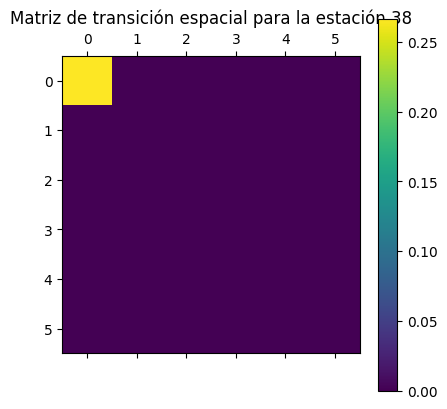

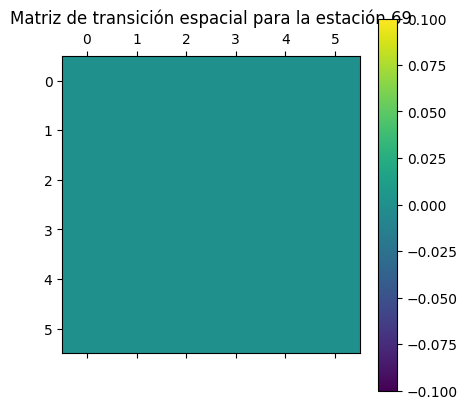

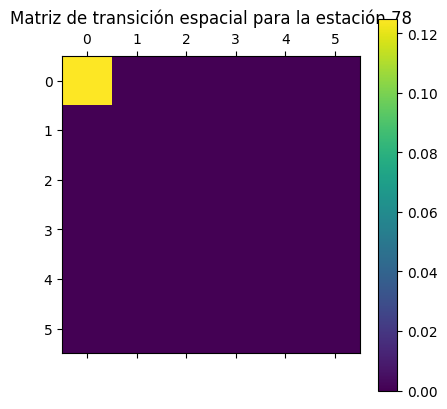

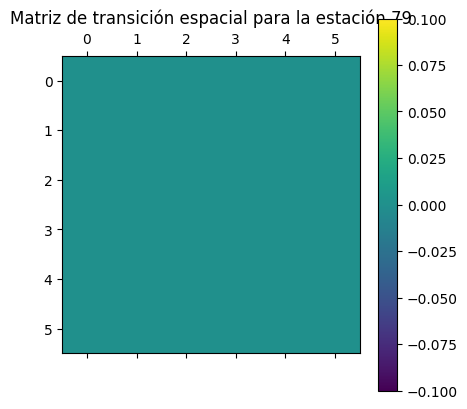

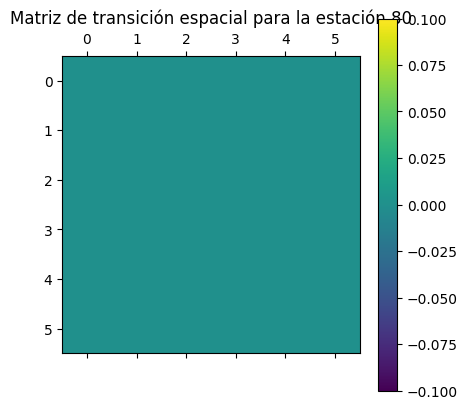

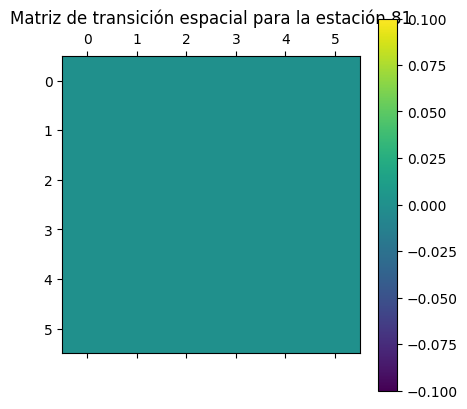

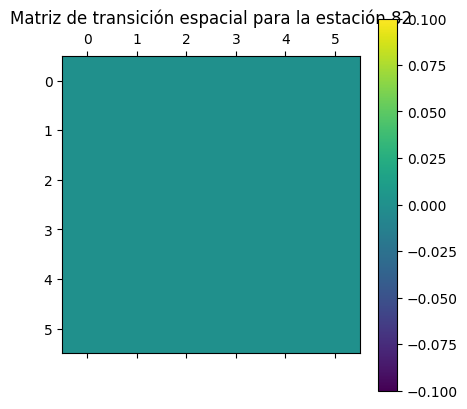

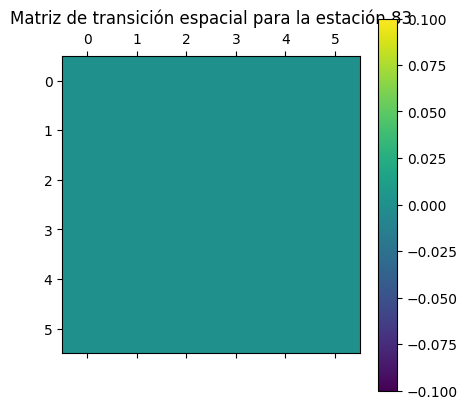

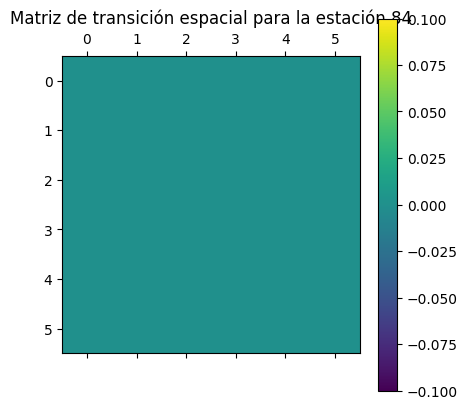

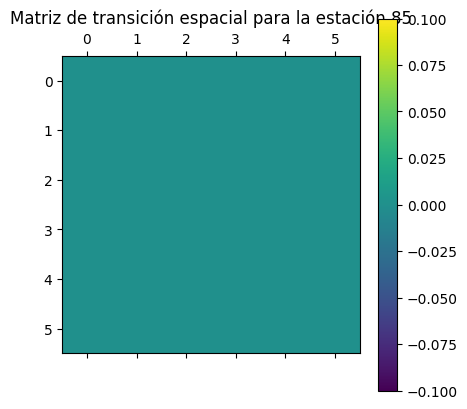

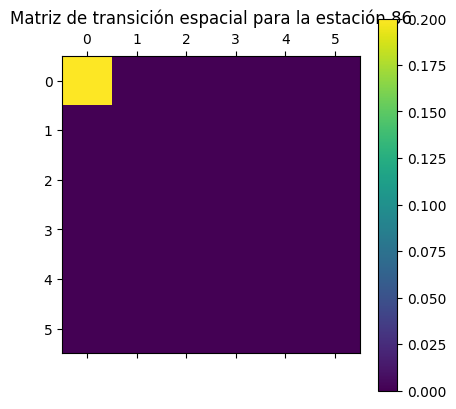

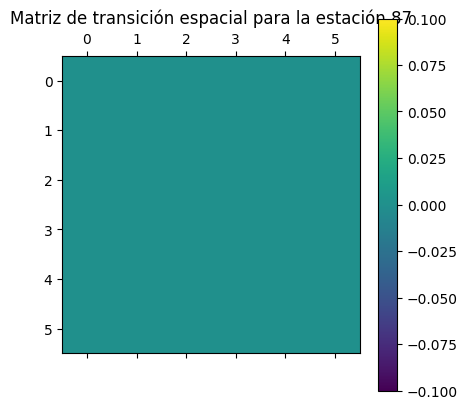

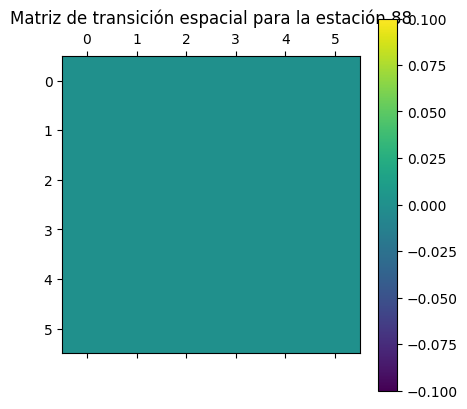

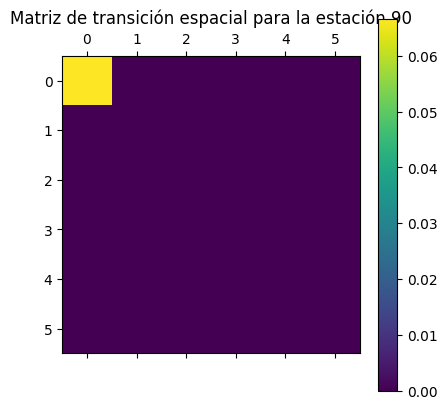

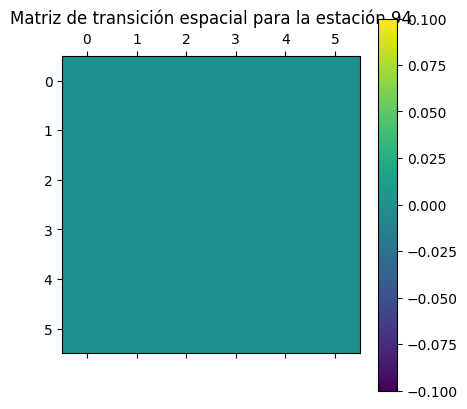

In [ ]:
import numpy as np
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi
import geopandas as gpd
from shapely.geometry import Polygon, Point

# Función para calcular la matriz de conteo de transiciones a partir de una secuencia dada
def calcular_matriz_conteo_transiciones(secuencia):
    transiciones = defaultdict(int)
    for i in range(len(secuencia) - 1):
        transicion = (secuencia[i], secuencia[i + 1])
        transiciones[transicion] += 1
    num_estados = max(max(transiciones.keys())) + 1
    matriz_conteo_transiciones = np.zeros((num_estados, num_estados), dtype=int)
    for transicion, conteo in transiciones.items():
        origen, destino = transicion
        matriz_conteo_transiciones[origen][destino] = conteo
    return matriz_conteo_transiciones

# Función para hallar la matriz de transición, en base a la matriz de conteo
def matriz_transicion(matriz, n):
    filas_sumadas = np.sum(matriz, axis=1)
    matriz_transiciones = np.divide(matriz.T, filas_sumadas, where=filas_sumadas != 0).T
    return matriz_transiciones

# Coordenadas reales de las estaciones
estaciones_coord = {
    28: (-75.5972, 6.1856),
    38: (-75.6443, 6.1684971),
    69: (-75.637764, 6.0930777),
    78: (-75.6441727, 6.1555305),
    79: (-75.61060329999999, 6.2218938),
    80: (-75.5482635, 6.2589092),
    81: (-75.3303986, 6.4369602),
    82: (-75.5047531, 6.3453598),
    83: (-75.610466, 6.2372341),
    84: (-75.5609512, 6.199870),
    85: (-75.6364288, 6.2778502),
    86: (-75.5555191, 6.2904806),
    87: (-75.5678024, 6.3375502),
    88: (-75.5819702, 6.1686831),
    90: (-75.6212616, 6.1455002),
    94: (-75.4984741, 6.236361)
}

# Crear DataFrame con las coordenadas
coords = pd.DataFrame.from_dict(estaciones_coord, orient='index', columns=['longitud', 'latitud'])

# Agregar una pequeña perturbación a las coordenadas para evitar la coplanaridad
perturbacion = 1e-6
coords['longitud'] += perturbacion * np.random.randn(len(coords))
coords['latitud'] += perturbacion * np.random.randn(len(coords))

# Generar polígonos de Voronoi
vor = Voronoi(coords[['longitud', 'latitud']])
polygons = []
for region in vor.regions:
    if not -1 in region and len(region) > 0:
        polygons.append(Polygon([vor.vertices[i] for i in region]))

# Crear GeoDataFrame de los polígonos de Voronoi
gdf = gpd.GeoDataFrame(geometry=polygons)

# Crear GeoDataFrame de las estaciones
gdf_estaciones = gpd.GeoDataFrame(coords, geometry=gpd.points_from_xy(coords['longitud'], coords['latitud']))

# Crear matriz de pesos espaciales basada en la contigüidad de los polígonos de Voronoi
spatial_join = gpd.sjoin(gdf_estaciones, gdf, how="left", predicate='intersects')

# Verificar las columnas resultantes del spatial join
print(spatial_join.columns)

# Crear el diccionario W
W = spatial_join.groupby(spatial_join.index)['index_right'].apply(list).to_dict()

# Normalizar la matriz de pesos espaciales
W_normalized = {}
for key, neighbors in W.items():
    W_normalized[key] = {}
    for neighbor in neighbors:
        W_normalized[key][neighbor] = 1 / len(neighbors)

# Función para calcular la matriz de transición espacial
def matriz_transicion_espacial(W, matrices_transicion, n):
    matrices_espaciales = {}
    for estacion, matriz in matrices_transicion.items():
        matriz_espacial = np.zeros((n, n))
        if estacion in W:
            for i in range(n):
                for j in range(n):
                    if i in matrices_transicion[estacion] and j in matrices_transicion[estacion][i]:
                        matriz_espacial[i, j] = matrices_transicion[estacion][i, j]
                    else:
                        matriz_espacial[i, j] = 0

            for neighbor, weight in W[estacion].items():
                if neighbor in matrices_transicion:
                    for i in range(n):
                        for j in range(n):
                            matriz_espacial[i, j] += matrices_transicion[neighbor][i, j] * weight

        matrices_espaciales[estacion] = matriz_espacial

    return matrices_espaciales

# Ejemplo de uso
matrices_transicion_espaciales = matriz_transicion_espacial(W_normalized, matrices_transicion, 6)


#
dfs = {est: pd.DataFrame(np.random.rand(100, 2), columns=['Fecha_Hora', 'pm25']) for est in estaciones_coord.keys()}
listas_pm25 = {est: np.random.randint(0, 6, size=100) for est in estaciones_coord.keys()}

matrices_transicion = {}
for estacion in dfs.keys():
    matriz_conteo_transiciones = calcular_matriz_conteo_transiciones(listas_pm25[estacion])
    n = len(matriz_conteo_transiciones)
    matriz_transicion_estacion = matriz_transicion(matriz_conteo_transiciones, n)
    matrices_transicion[estacion] = matriz_transicion_estacion

# Verificar las claves en matrices_transicion y W_normalized
print("Claves en matrices_transicion:", matrices_transicion.keys())
print("Claves en W_normalized:", W_normalized.keys())

# Calcular las matrices de transición espaciales
matrices_transicion_espaciales = matriz_transicion_espacial(W_normalized, matrices_transicion, 6)

# Imprimir las matrices de transición espaciales
#for estacion, matriz in matrices_transicion_espaciales.items():
    #plt.matshow(matriz)
    #plt.colorbar()
    #plt.title(f'Matriz de transición espacial para la estación {estacion}')
    #plt.show()
    # plt.savefig(f'matriz_transicion_espacial_estacion_{estacion}.png')


In [ ]:
print(matrices_transicion_espaciales.keys())


dict_keys([28, 38, 69, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 90, 94])
